In [ ]:
!pip install ultralytics
!pip install ultralytics split-folders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.1 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from ultralytics import YOLO
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive
drive.mount('/content/drive')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive


In [ ]:
# Path Config
DRIVE_PATH = "/content/drive/MyDrive/MU_ICT_DST/Year_3/Semester_2/DS/Cropped Dataset 3" # Change Dataset Path
RAW_PATH = "/content/raw_data"
BASE_DATA_PATH = "/content/yolo26_kfold"

# Copy Dataset from drive to local
if os.path.exists(DRIVE_PATH):
    if os.path.exists(RAW_PATH): shutil.rmtree(RAW_PATH)
    shutil.copytree(DRIVE_PATH, RAW_PATH)
    print("Copied Data from Drive")
else:
    raise FileNotFoundError(f"Not found in Drive: {DRIVE_PATH}")

Copied Data from Drive


In [ ]:
# Set Class Label
classes = sorted([d for d in os.listdir(RAW_PATH) if os.path.isdir(os.path.join(RAW_PATH, d))])
all_files = []
for cls in classes:
    cls_path = os.path.join(RAW_PATH, cls)
    files = [os.path.join(cls, f) for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_files.extend(files)

all_files = np.array(all_files)

# Set Fold
K_FOLDS = 5
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
overall_y_true = []
overall_y_pred = []
fold_accuracies = []

In [ ]:
# Fold loop
for fold, (train_idx, val_idx) in enumerate(kf.split(all_files)):
    print(f"\n" + "🌀" * 20)
    print(f"🔥 YOLO 26 - FOLD {fold + 1}/{K_FOLDS}")
    print("🌀" * 20)

    # Create Folder Path Fold by FOld
    FOLD_PATH = f"{BASE_DATA_PATH}/fold_{fold+1}"
    if os.path.exists(FOLD_PATH): shutil.rmtree(FOLD_PATH)

    for split in ['train', 'val']:
        for cls in classes:
            os.makedirs(os.path.join(FOLD_PATH, split, cls), exist_ok=True)

    # Add train/val on each fold folder
    for f in all_files[train_idx]:
        shutil.copy(os.path.join(RAW_PATH, f), os.path.join(FOLD_PATH, 'train', f))
    for f in all_files[val_idx]:
        shutil.copy(os.path.join(RAW_PATH, f), os.path.join(FOLD_PATH, 'val', f))

    # YOLO26 setting
    model = YOLO('yolo26n-cls.pt')
    model.train(
        data=FOLD_PATH,
        epochs=200,
        patience=200,
        imgsz=224,
        batch=32,
        name=f'yolo26_fold_{fold+1}',
        device='0',
        exist_ok=True,
        verbose=False
    )

    # VAL
    best_path = f'runs/classify/yolo26_fold_{fold+1}/weights/best.pt'
    if os.path.exists(best_path):
        best_model = YOLO(best_path)

        # VAL Image find path
        val_img_paths = []
        for cls in classes:
            val_img_paths.extend(glob.glob(f"{FOLD_PATH}/val/{cls}/*"))

        # Predict
        results = best_model.predict(source=val_img_paths, imgsz=224, conf=0.25, verbose=False)

        fold_y_true = []
        fold_y_pred = []

        for i, r in enumerate(results):
            p_val = r.probs.top1
            pred_idx = int(p_val.cpu().numpy()) if hasattr(p_val, 'cpu') else int(p_val)
            fold_y_pred.append(pred_idx)

            path_parts = os.path.normpath(val_img_paths[i]).split(os.sep)
            true_label = path_parts[-2]
            fold_y_true.append(classes.index(true_label))

        overall_y_true.extend(fold_y_true)
        overall_y_pred.extend(fold_y_pred)

        # Accuracy Calculations
        acc = (np.array(fold_y_true) == np.array(fold_y_pred)).mean()
        fold_accuracies.append(acc)
        print(f"✅ Fold {fold+1} สำเร็จ! Accuracy: {acc*100:.2f}%")

Streaming output truncated to the last 5000 lines.
      Epoch    GPU_mem       loss  Instances       Size
     48/200     0.551G     0.1227         31        224: 100% ━━━━━━━━━━━━ 9/9 6.5it/s 1.4s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 2/2 16.9it/s 0.1s
                   all      0.833          1

      Epoch    GPU_mem       loss  Instances       Size
     49/200     0.551G     0.1052         31        224: 100% ━━━━━━━━━━━━ 9/9 9.1it/s 1.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 2/2 27.3it/s 0.1s
                   all      0.875          1

      Epoch    GPU_mem       loss  Instances       Size
     50/200     0.551G     0.1029         31        224: 100% ━━━━━━━━━━━━ 9/9 7.9it/s 1.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 2/2 19.3it/s 0.1s
                   all      0.778          1

      Epoch    GPU_mem       loss  Instances       Size
     51/200     0.551G     0.1114         31        224: 100% ━━━


📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊
🌟 สรุปผล CROSS VALIDATION (YOLO 26)
ค่าเฉลี่ย Accuracy: 91.10%
📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊

📝 Overall Report:
              precision    recall  f1-score   support

     class 0       0.91      0.96      0.94        75
     class 1       0.90      0.90      0.90        59
     class 2       0.91      0.86      0.88        70
     class 3       0.92      0.91      0.91        75
     class 4       0.91      0.93      0.92        80

    accuracy                           0.91       359
   macro avg       0.91      0.91      0.91       359
weighted avg       0.91      0.91      0.91       359



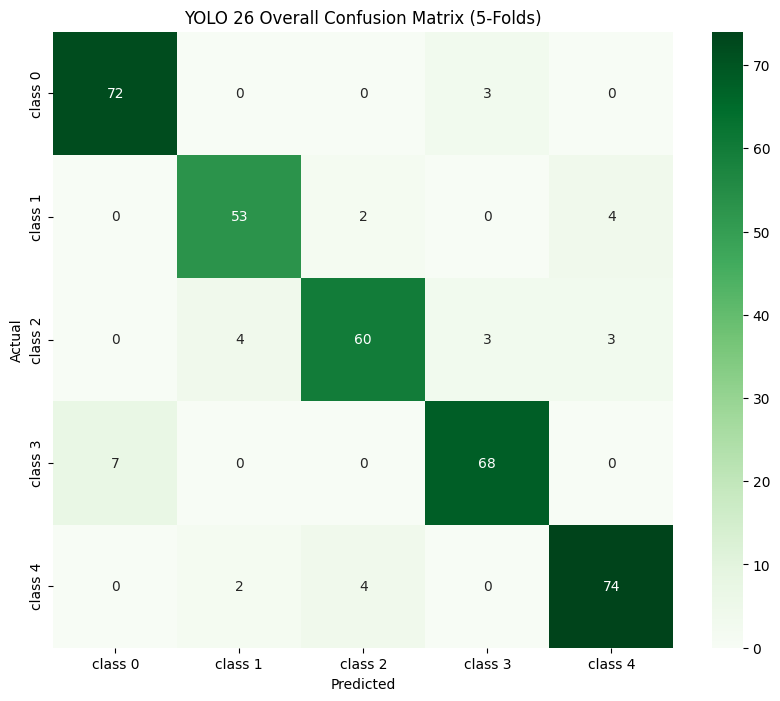

In [ ]:
# Report
print("\n" + "📊" * 15)
print(f"🌟 สรุปผล CROSS VALIDATION (YOLO 26)")
print(f"ค่าเฉลี่ย Accuracy: {np.mean(fold_accuracies)*100:.2f}%")
print("📊" * 15)

# Classification Report
print("\n📝 Overall Report:")
print(classification_report(overall_y_true, overall_y_pred, target_names=classes))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(overall_y_true, overall_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title(f'YOLO 26 Overall Confusion Matrix ({K_FOLDS}-Folds)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
import shutil
import numpy as np

# save model ลง Google Drive

# หา Model ที่ดีที่สุด
best_fold = int(np.argmax(fold_accuracies)) + 1
print(f"Best Fold: {best_fold} | Accuracy: {fold_accuracies[best_fold-1]*100:.2f}%")

# Define ก่อน copy
best_model_src = f"runs/classify/yolo26_fold_{best_fold}/weights/best.pt"

# Save Path
save_path = "/content/drive/MyDrive/MU_ICT_DST/Year_3/Semester_2/DS/yolo26cls_best_model.pt"
shutil.copy(best_model_src, save_path)
print(f"Saved model to: {save_path}")

Best Fold: 1 | Accuracy: 94.44%
Saved model to: /content/drive/MyDrive/MU_ICT_DST/Year_3/Semester_2/DS/yolo26cls_best_model.pt


Saving 1_0.jpg to 1_0.jpg
1_0.jpg → class_1 (100.0%)


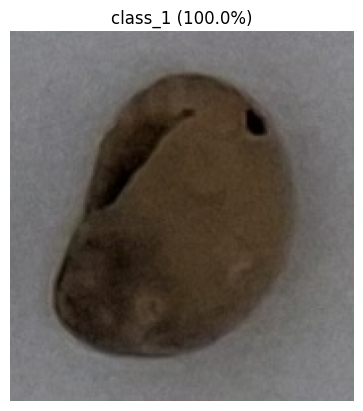

In [ ]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
import io

# Load Model
model = YOLO('/content/drive/MyDrive/MU_ICT_DST/Year_3/Semester_2/DS/yolo26cls_best_model.pt') # Mdeol Path

# Set Class Label
CLASS_NAMES = ['class_0', 'class_1', 'class_2', 'class_3', 'class_4']

# Upload image from your file
uploaded = files.upload()

for filename, content in uploaded.items():
    img = Image.open(io.BytesIO(content)).convert('RGB')

    results = model.predict(source=img, imgsz=224, verbose=False)
    probs = results[0].probs.data.cpu().numpy()

    # Model answer
    pred = CLASS_NAMES[probs.argmax()]
    print(f"{filename} → {pred} ({probs.max()*100:.1f}%)")

    plt.imshow(img)
    plt.title(f"{pred} ({probs.max()*100:.1f}%)")
    plt.axis('off')
    plt.show()